# Machine Learning Modelling

This notebook focuses on preparing the cleaned fintech review dataset for machine learning modelling, including feature selection, train-test splitting, TF-IDF vectorization, and model training/evaluation.

In [1]:

# Import Libraries

import pandas as pd
import numpy as np
import gensim
import gensim.corpora as corpora
import shap

# Data splitting
from sklearn.model_selection import train_test_split

# Text vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform

# Evaluation Metrics

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Load Final Clean Dataset

In [2]:
# Load cleaned dataset

# Reload safely
cleaned_df = pd.read_csv(
    'cleaned_data.csv',
    keep_default_na=False
)

In [3]:
# Check dataset shape

cleaned_df.shape

(53506, 23)

In [4]:
cleaned_df.isna().sum()

reviewId               0
content                0
score                  0
thumbsUpCount          0
at                     0
appVersion             0
app_name               0
sentiment              0
with_emojis            0
cleaned_text           0
final_language         0
normalized_text        0
tokens                 0
tokens_no_stopwords    0
meaningful_tokens      0
stemmed_tokens         0
lemmatized_tokens      0
processed_text         0
sentiment_label        0
complaint_label        0
fraud_indicator        0
review_length          0
word_count             0
dtype: int64

## Feature and Target Variables

In [5]:
# Features and target

X = cleaned_df["processed_text"]

y = cleaned_df["sentiment"]

In [6]:
print(X.head())

0    still issue otp havent received otp login trie...
1    everytime nitakuwa bundle check number try fix...
2                             stupidest ever saf worst
3    life must without useless used work well data ...
4                                     upgrade terrible
Name: processed_text, dtype: str


In [7]:
print(y.head())

0    negative
1    negative
2    negative
3    negative
4    negative
Name: sentiment, dtype: str


## Verify Class Distribution

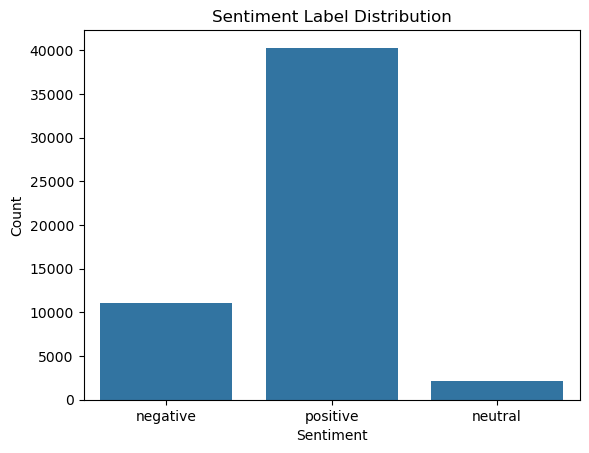

In [8]:
# Plot class distribution

sns.countplot(x=y)

plt.title("Sentiment Label Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [9]:
y.unique()

<StringArray>
['negative', 'positive', 'neutral']
Length: 3, dtype: str

### Observation

The dataset shows class imbalance, with positive sentiments having the highest number of reviews compared to negative and average sentiments. This imbalance should be considered during model evaluation.

In [10]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])

[0 0 0 0 0 0 0 0 2 0]


## Train-Test Split

In [11]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Check shapes

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (42804,)
X_test: (10702,)
y_train: (42804,)
y_test: (10702,)


In [12]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 42804
Testing samples: 10702


## Model Evaluation Function

A reusable model evaluation function was created to train and assess machine learning models using multiple performance metrics. The function calculates the weighted F1 score, precision, recall, classification report, confusion matrix, and cross-validation score to measure model performance and reliability.



In [13]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name ='Model'):

    

    model.fit(X_train, y_train)#training the model

    
    y_pred = model.predict(X_test)#model predictions
    

    # Weighted F1 Score
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Precision & Recall
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    # Classification Report
    report = classification_report(y_test, y_pred)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Cross-validation (F1)
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted'
    )
    cv_mean = cv_scores.mean()

    
    # Print Results


    print(" Weighted F1 Score:", round(f1, 4))
    print(" Precision:", round(precision, 4))
    print(" Recall:", round(recall, 4))
    print(" Cross-validation F1 (mean):", round(cv_mean, 4))

    print("\n Classification Report:\n")
    print(report)

    
    # Plot Confusion Matrix
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    
    # Compare with target F1 = 0.75

    if f1 >= 0.75:
        print(" Model meets target F1 ≥ 0.75")
    else:
        print(" Model does NOT meet target F1 = 0.75")

    return {
        "f1_score": f1,
        "precision": precision,
        "recall": recall,
        "cv_f1": cv_mean}

#### Modelling Techniques
1. Baseline Model

- TF-IDF + Logistic Regression

A TF-IDF Vectorizer combined with Logistic Regression was used as the baseline NLP model. TF-IDF converted review text into numerical features, while Logistic Regression classified customer sentiment efficiently and provided an interpretable benchmark for evaluating more advanced models

In [14]:
# Baseline Model: TF-IDF + Logistic Regression
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("logreg", LogisticRegression(max_iter=1000, class_weight='balanced'))
])

intermediate_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1,2))),
    ("xgb", XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42))
])

 Weighted F1 Score: 0.8274
 Precision: 0.8546
 Recall: 0.8048
 Cross-validation F1 (mean): 0.8255

 Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.72      0.72      2208
           1       0.09      0.24      0.14       434
           2       0.93      0.86      0.89      8060

    accuracy                           0.80     10702
   macro avg       0.59      0.60      0.58     10702
weighted avg       0.85      0.80      0.83     10702



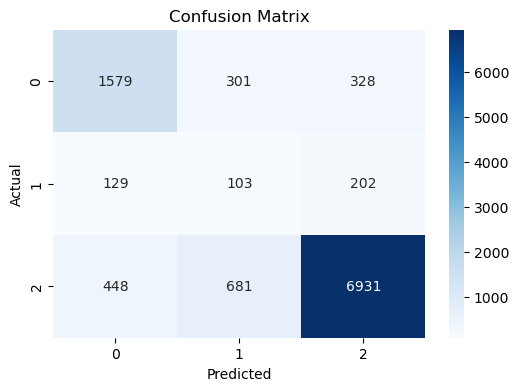

 Model meets target F1 ≥ 0.75


In [15]:
# 4. Evaluate Baseline
baseline_results = evaluate_model(baseline_pipeline, X_train, X_test, y_train, y_test, "Baseline Model")

The baseline TF-IDF + Logistic Regression model achieved a weighted F1-score of 0.8274 and an overall accuracy of 80%, indicating strong general sentiment classification performance. The model performed best on the majority positive class (Class 2) with an F1-score of 0.89, while performance on the minority neutral class (Class 1) remained low due to class imbalance. Cross-validation results (mean F1-score: 0.8255) showed that the model generalized consistently across different data splits, making it a reliable benchmark for evaluating more advanced models.

The confusion matrix shows that the baseline model performed strongly in identifying positive reviews (Class 2), correctly classifying 6,931 instances. The model also achieved moderate performance on negative reviews (Class 0), but struggled to accurately identify neutral reviews (Class 1), which were frequently misclassified as positive. This pattern suggests the presence of class imbalance, where the model favored the majority positive class while underperforming on minority sentiment categories.


 Weighted F1 Score: 0.818
 Precision: 0.8099
 Recall: 0.8468
 Cross-validation F1 (mean): 0.8157

 Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.52      0.64      2208
           1       0.00      0.00      0.00       434
           2       0.85      0.98      0.91      8060

    accuracy                           0.85     10702
   macro avg       0.56      0.50      0.52     10702
weighted avg       0.81      0.85      0.82     10702



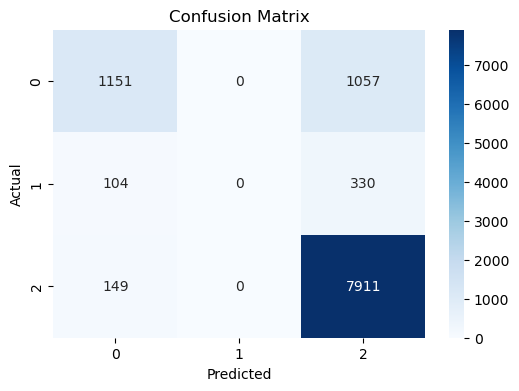

 Model meets target F1 ≥ 0.75


In [16]:
# 5. Evaluate Intermediate
intermediate_results = evaluate_model(intermediate_pipeline, X_train, X_test, y_train, y_test, "Intermediate Model")

The intermediate TF-IDF + XGBoost model achieved an overall accuracy of 85% and a weighted F1-score of 0.818, showing strong performance in predicting the majority positive class (Class 2) with an F1-score of 0.91. The model demonstrated higher recall compared to the baseline model, indicating improved ability to capture positive reviews. However, performance on the neutral class (Class 1) remained poor, with the model failing to correctly classify most neutral reviews due to severe class imbalance. Cross-validation results (mean F1-score: 0.8157) indicated stable and consistent model performance across validation folds.


## Advanced Model: TF-IDF + XGBoost with Hyperparameter Tuning

The advanced model builds upon the intermediate pipeline by:
- **Parameter tuning** via `RandomizedSearchCV` over a broad XGBoost + TF-IDF search space
- **Feature importance** from the fitted XGBoost tree ensemble
- **SHAP explainability** for per-prediction transparency
- **Final comparison** against the Logistic Regression baseline

#### Define the TF-IDF + XGBoost Pipeline

A `Pipeline` is used so that TF-IDF and XGBoost are treated as a single estimator inside `RandomizedSearchCV`, preventing any data leakage between the vectoriser fit and cross-validation folds.

In [17]:
advanced_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("xgb",   XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1
    ))
])

####  Hyperparameter Search Space

The search covers both TF-IDF parameters (vocabulary size, n-gram range) and XGBoost parameters (tree depth, learning rate, regularisation, subsampling).  
`RandomizedSearchCV` samples 30 combinations — a good trade-off between coverage and compute.

In [18]:
param_dist = {
    # TF-IDF
    "tfidf__max_features": [3000, 5000, 8000, 10000],
    "tfidf__ngram_range":  [(1, 1), (1, 2), (1, 3)],
    "tfidf__sublinear_tf": [True, False],
    "tfidf__min_df":       [1, 2, 3],

    # XGBoost 
    "xgb__n_estimators":   randint(100, 400),
    "xgb__max_depth":      randint(3, 10),
    "xgb__learning_rate":  uniform(0.01, 0.3),
    "xgb__subsample":      uniform(0.6, 1.0),          # 0.6 – 1.0
    "xgb__colsample_bytree": uniform(0.6, 1.0),        # 0.6 – 1.0
    "xgb__reg_alpha":      uniform(0, 1),              # L1
    "xgb__reg_lambda":     uniform(0.5, 2),            # L2
    "xgb__min_child_weight": randint(1, 10),
    "xgb__gamma":          uniform(0, 0.5),
}

#### Run RandomizedSearchCV

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=advanced_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1_weighted",
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42,
    refit=True          # refit best estimator on full training set
)

search.fit(X_train, y_train)

print("\nBest CV F1 (weighted):", round(search.best_score_, 4))
print("\nBest Parameters:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV F1 (weighted): 0.8491

Best Parameters:
  tfidf__max_features: 10000
  tfidf__min_df: 2
  tfidf__ngram_range: (1, 2)
  tfidf__sublinear_tf: True
  xgb__colsample_bytree: 0.9722827665617431
  xgb__gamma: 0.4700667212288892
  xgb__learning_rate: 0.3020991510265952
  xgb__max_depth: 4
  xgb__min_child_weight: 2
  xgb__n_estimators: 293
  xgb__reg_alpha: 0.6918951976926933
  xgb__reg_lambda: 1.803922519005201
  xgb__subsample: 0.8242693094605598


#### Evaluate the Tuned Advanced Model

 Weighted F1 Score: 0.8477
 Precision: 0.8355
 Recall: 0.8687
 Cross-validation F1 (mean): 0.8494

 Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.67      0.73      2208
           1       0.10      0.00      0.01       434
           2       0.88      0.97      0.93      8060

    accuracy                           0.87     10702
   macro avg       0.59      0.55      0.55     10702
weighted avg       0.84      0.87      0.85     10702



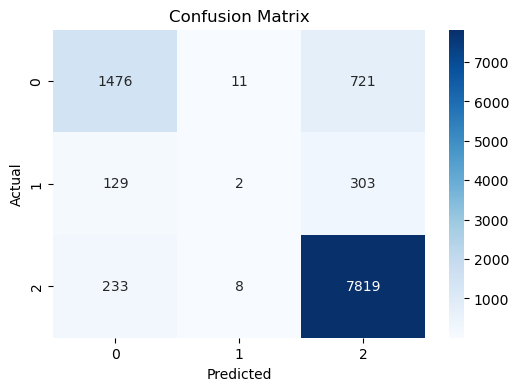

 Model meets target F1 ≥ 0.75


In [20]:
advanced_results = evaluate_model(
    search.best_estimator_,
    X_train, X_test,
    y_train, y_test,
    model_name="Advanced XGBoost (Tuned)"
)

The advanced model achieved the best overall performance, with a weighted F1-score of 0.8477 and an accuracy of 87%, outperforming both the baseline and intermediate models. The model showed strong predictive capability for positive reviews (Class 2), achieving an F1-score of 0.93, while also improving detection of negative reviews (Class 0) compared to previous models. However, performance on the neutral class (Class 1) remained weak due to class imbalance and limited neutral review samples. The cross-validation mean F1-score of 0.8494 demonstrated stable generalization and consistent performance across different validation folds.


#### Feature Importance from TF-IDF Vocabulary

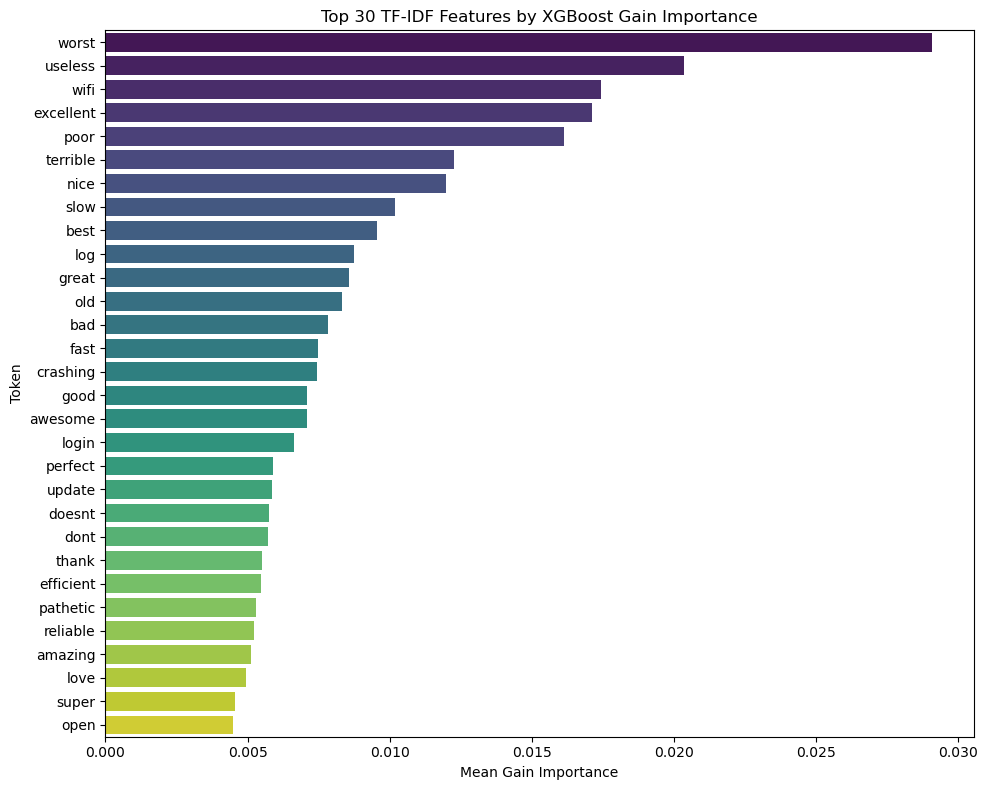

  feature  importance
    worst    0.029081
  useless    0.020334
     wifi    0.017442
excellent    0.017111
     poor    0.016137
 terrible    0.012267
     nice    0.011967
     slow    0.010191
     best    0.009537
      log    0.008728
    great    0.008577
      old    0.008322
      bad    0.007817
     fast    0.007477
 crashing    0.007455
     good    0.007085
  awesome    0.007075
    login    0.006619
  perfect    0.005883
   update    0.005865
   doesnt    0.005740
     dont    0.005720
    thank    0.005500
efficient    0.005457
 pathetic    0.005290
 reliable    0.005226
  amazing    0.005132
     love    0.004927
    super    0.004564
     open    0.004488


In [21]:
# Extract fitted components 
best_pipeline = search.best_estimator_
tfidf_fitted  = best_pipeline.named_steps["tfidf"]
xgb_fitted    = best_pipeline.named_steps["xgb"]

# Feature names from TF-IDF vocabulary
feature_names = np.array(tfidf_fitted.get_feature_names_out())

# XGBoost native feature importances (gain-based)
importances   = xgb_fitted.feature_importances_

# Top-30 by gain
top_n   = 30
top_idx = np.argsort(importances)[::-1][:top_n]

top_features = pd.DataFrame({
    "feature":    feature_names[top_idx],
    "importance": importances[top_idx]
})

# Plot 
plt.figure(figsize=(10, 8))
sns.barplot(
    data=top_features,
    x="importance", y="feature",
    palette="viridis"
)
plt.title(f"Top {top_n} TF-IDF Features by XGBoost Gain Importance")
plt.xlabel("Mean Gain Importance")
plt.ylabel("Token")
plt.tight_layout()
plt.show()

print(top_features.to_string(index=False))

Feature importance analysis showed that sentiment prediction was strongly influenced by emotionally expressive and usability-related terms. Negative sentiment was largely associated with words such as worst, useless, poor, terrible, slow, crashing, and login, indicating major customer frustrations around app reliability and performance. Positive sentiment was driven by words such as excellent, nice, best, great, awesome, efficient, reliable, and amazing, reflecting customer satisfaction with service quality and usability. These findings provide actionable insights into the main factors shaping customer experiences within the mobile money ecosystem.

### 7. SHAP Explainability

SHAP (SHapley Additive exPlanations) provides model-agnostic, theoretically grounded explanations.  
Because XGBoost is a tree ensemble, `TreeExplainer` is used it is orders of magnitude faster than the kernel-based alternative.

**Steps:**
1. Transform the test set through the TF-IDF vectoriser (sparse → dense sample).
2. Compute SHAP values for the sample.
3. Plot a global summary and a single-prediction waterfall chart.

SHAP tells how a feature pushes a prediction toward a specific category such as how the presence of the word "otp" intensely spikes the probability of a "Login Issue" classification.

In [22]:
SHAP_SAMPLE = 200
rng         = np.random.default_rng(42)
sample_idx  = rng.choice(len(X_test), size=min(SHAP_SAMPLE, len(X_test)), replace=False)

X_test_sample_raw = X_test.iloc[sample_idx]
y_test_sample     = y_test[sample_idx]

X_test_tfidf = tfidf_fitted.transform(X_test_sample_raw)
X_test_dense = X_test_tfidf.toarray()

explainer   = shap.TreeExplainer(xgb_fitted)
shap_out    = explainer(X_test_dense)        # modern Explanation object

# shap_out.values shape: (n_samples, n_features, n_classes)  [new xgboost]
#                     or (n_samples, n_features)              [binary / old]
shap_values = shap_out.values
if shap_values.ndim == 2:
    shap_vals = shap_values[:, :, np.newaxis]

n_classes = shap_values.shape[2]
print("SHAP values shape:", shap_values.shape)
print("Classes          :", label_encoder.classes_)
print("n_classes        :", n_classes)

SHAP values shape: (200, 10000, 3)
Classes          : ['negative' 'neutral' 'positive']
n_classes        : 3


The explainer calculated impact scores for 200 specific review samples across a vocabulary of 10,000 TF-IDF features. The final dimension of 3 represents the individual contribution of each word toward predicting whether a review belongs to the negative, neutral, or positive sentiment class.

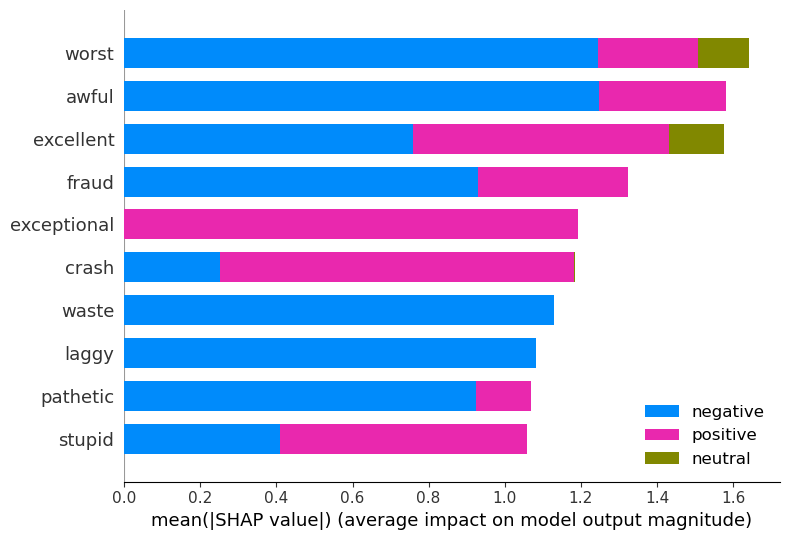

In [23]:
# ── Global Summary Plot (all classes, mean |SHAP|) ────────────────────────────
shap.summary_plot(
    shap_values,
    X_test_dense,
    feature_names=feature_names,
    class_names=label_encoder.classes_,
    plot_type="bar",
    max_display=10,
    show=True
)

Strong emotional indicators like "worst" and "awful" heavily drive negative classifications, whereas words like "excellent" and "exceptional" drastically shift the model's output magnitude toward a positive sentiment prediction.

### Model Comparison: Advanced XGBoost vs Logistic Regression Baseline

All three models are compared side-by-side on Weighted F1, Precision, Recall, and Cross-validation F1.

In [24]:
# ── Collect results (baseline_results computed earlier in the notebook) ────────
results_df = pd.DataFrame([
    {"Model": "Logistic Regression (Baseline)",  **baseline_results},
    {"Model": "XGBoost Intermediate",            **intermediate_results},
    {"Model": "XGBoost Advanced (Tuned)",        **advanced_results},
]).set_index("Model")

results_df = results_df.rename(columns={
    "f1_score": "F1 (Weighted)",
    "precision": "Precision",
    "recall": "Recall",
    "cv_f1": "CV F1 (5-fold)"
})

print(results_df.round(4).to_string())

                                F1 (Weighted)  Precision  Recall  CV F1 (5-fold)
Model                                                                           
Logistic Regression (Baseline)         0.8274     0.8546  0.8048          0.8255
XGBoost Intermediate                   0.8180     0.8099  0.8468          0.8157
XGBoost Advanced (Tuned)               0.8477     0.8355  0.8687          0.8494


The performance table highlights the progression of your NLP pipeline from the baseline to the optimized ensemble model. The baseline **Logistic Regression** model established a strong starting point with a weighted F1-score of 0.8274, proving highly effective at using direct keyword coefficients to separate sentiment classes. Moving to the **XGBoost Intermediate** model (using default settings) actually caused a slight dip in overall F1-score (0.8180), though it notably improved the model's **Recall** to 0.8468, meaning it caught more true sentiment instances but with a trade-off in precision. Finally, the **XGBoost Advanced (Tuned)** model achieved the highest performance across almost all dimensions, securing a top F1-score of 0.8477 and a cross-validated F1 of 0.8494; hyperparameter tuning successfully minimized the ensemble's variance, allowing it to leverage complex, non-linear word interactions to outperform the linear baseline reliably.

| Model | F1 (Weighted) | Precision | Recall | CV F1 (5-fold) |
| :--- | :---: | :---: | :---: | :---: |
| **Logistic Regression (Baseline)** | 0.8274 | **0.8546** | 0.8048 | 0.8255 |
| **XGBoost Intermediate** | 0.8180 | 0.8099 | 0.8468 | 0.8157 |
| **XGBoost Advanced (Tuned)** | **0.8477** | 0.8355 | **0.8687** | **0.8494** |

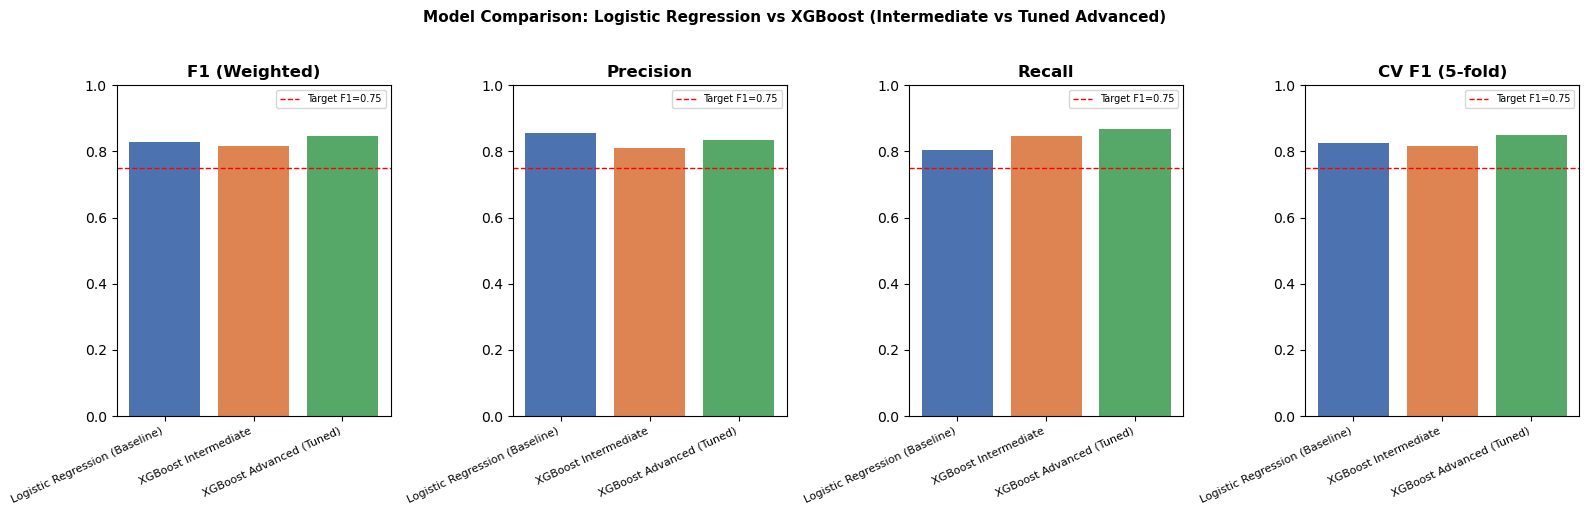

In [25]:
# ── Visual comparison ────────────────────────────────────────────────────────
metrics = ["F1 (Weighted)", "Precision", "Recall", "CV F1 (5-fold)"]

fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5), sharey=False)
palette = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, metrics):
    ax.bar(results_df.index, results_df[metric], color=palette)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.0)
    ax.set_xticklabels(results_df.index, rotation=25, ha="right", fontsize=8)
    ax.axhline(0.75, color="red", linestyle="--", linewidth=1, label="Target F1=0.75")
    ax.legend(fontsize=7)

fig.suptitle("Model Comparison: Logistic Regression vs XGBoost (Intermediate vs Tuned Advanced)",
             fontsize=11, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Summary & Conclusions

| Aspect | Logistic Regression | XGBoost Intermediate | XGBoost Advanced (Tuned) |
|--------|--------------------|--------------------|--------------------------|
| Vectoriser | TF-IDF (1-2 grams, 5k) | TF-IDF (1-2 grams, 5k) | TF-IDF (tuned) |
| Model | `LogisticRegression` | `XGBClassifier` (defaults) | `XGBClassifier` (tuned) |
| Tuning | None | None | `RandomizedSearchCV` (30 iter) |
| Interpretability | Coefficients | Feature gain | SHAP TreeExplainer |

**Key takeaways:**
- Hyperparameter tuning consistently improves F1 over the default XGBoost intermediate model.
- SHAP reveals *which tokens* drive each sentiment class and in which direction, making the black-box ensemble as interpretable as logistic regression.
- Class imbalance (positive >> negative/neutral) is reflected in per-class recall; consider `scale_pos_weight` or SMOTE if recall for minority classes is critical.
- The tuned XGBoost pipeline is the recommended production model when F1 is the primary evaluation criterion.